In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Hello Ganesh! Notebook is working.")

Hello Ganesh! Notebook is working.


In [10]:
import os

print(os.getcwd())

c:\Users\ganes\Desktop\bluestock_mf_capstone\notebooks


In [11]:
import os

print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv']


In [12]:
import pandas as pd

nav = pd.read_csv("../data/raw/02_nav_history.csv")

print(nav.head())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [13]:
print("Number of Rows and Columns:")
print(nav.shape)

Number of Rows and Columns:
(46000, 3)


In [14]:
print(nav.dtypes)

amfi_code      int64
date             str
nav          float64
dtype: object


In [15]:
# Convert date column into Date format

nav["date"] = pd.to_datetime(nav["date"])

print(nav.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


In [16]:
# Arrange the data by Fund ID and Date

nav = nav.sort_values(["amfi_code", "date"])

print(nav.head(10))

      amfi_code       date       nav
5750     100016 2022-01-03  520.4608
5751     100016 2022-01-04  515.0971
5752     100016 2022-01-05  521.7239
5753     100016 2022-01-06  515.7880
5754     100016 2022-01-07  515.1639
5755     100016 2022-01-10  510.7136
5756     100016 2022-01-11  513.5542
5757     100016 2022-01-12  512.3195
5758     100016 2022-01-13  510.2445
5759     100016 2022-01-14  514.3636


In [18]:
# Calculate Daily Return

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print(nav.head(10))

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
5756     100016 2022-01-11  513.5542      0.005562
5757     100016 2022-01-12  512.3195     -0.002404
5758     100016 2022-01-13  510.2445     -0.004050
5759     100016 2022-01-14  514.3636      0.008073


In [19]:
# Save Daily Returns

nav.to_csv(
    "../data/processed/daily_returns.csv",
    index=False
)

print("Daily Returns Saved Successfully!")

Daily Returns Saved Successfully!


In [20]:
# Summary Statistics of Daily Returns

print(nav["daily_return"].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


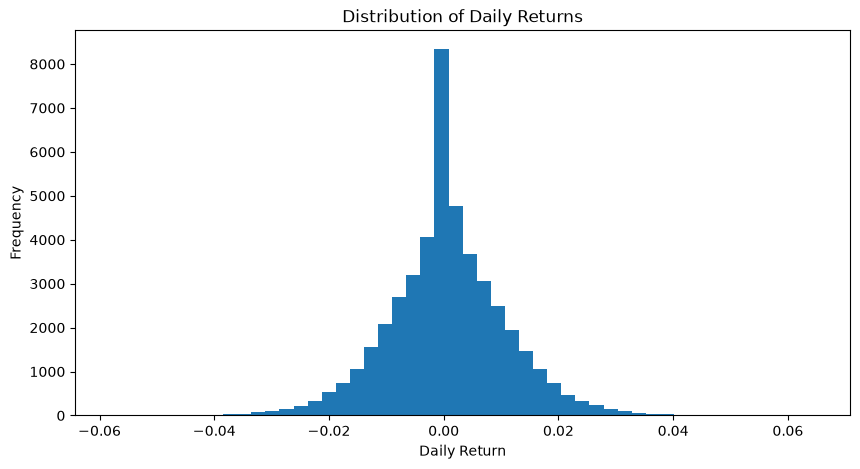

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(nav["daily_return"].dropna(), bins=50)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

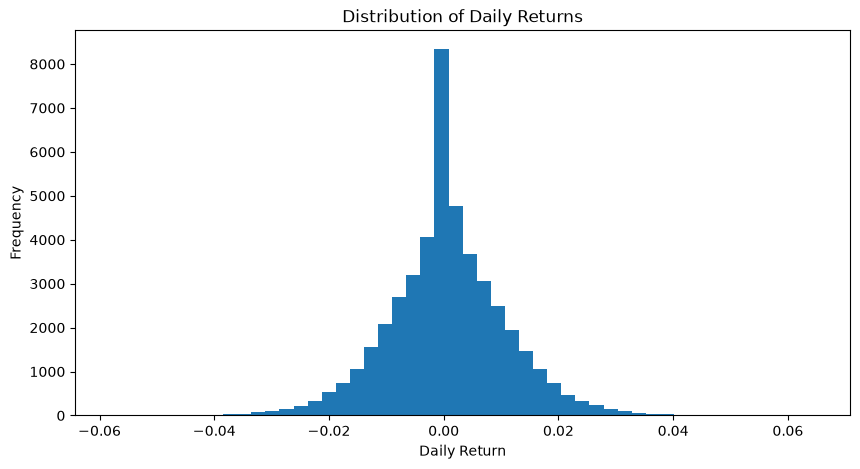

Graph Saved Successfully!


In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(nav["daily_return"].dropna(), bins=50)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.savefig("../reports/daily_return_distribution.png")

plt.show()

print("Graph Saved Successfully!")

In [23]:
# Make a copy of the NAV dataset

cagr_df = nav.copy()

print(cagr_df.head())

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210


In [24]:
# First and Last NAV of each Mutual Fund

first_last = cagr_df.groupby("amfi_code").agg(
    start_nav=("nav", "first"),
    end_nav=("nav", "last"),
    start_date=("date", "first"),
    end_date=("date", "last")
)

print(first_last.head())

           start_nav   end_nav start_date   end_date
amfi_code                                           
100016      520.4608  583.6113 2022-01-03 2026-05-29
100025       26.3169   31.8843 2022-01-03 2026-05-29
100033      107.3758  342.0072 2022-01-03 2026-05-29
101206      305.0996  773.2939 2022-01-03 2026-05-29
101207       38.5736   53.9836 2022-01-03 2026-05-29


In [25]:
# Calculate investment period in years

first_last["years"] = (
    (first_last["end_date"] - first_last["start_date"]).dt.days
) / 365.25

print(first_last.head())

           start_nav   end_nav start_date   end_date     years
amfi_code                                                     
100016      520.4608  583.6113 2022-01-03 2026-05-29  4.399726
100025       26.3169   31.8843 2022-01-03 2026-05-29  4.399726
100033      107.3758  342.0072 2022-01-03 2026-05-29  4.399726
101206      305.0996  773.2939 2022-01-03 2026-05-29  4.399726
101207       38.5736   53.9836 2022-01-03 2026-05-29  4.399726


In [26]:
# Calculate CAGR

first_last["CAGR"] = (
    (first_last["end_nav"] / first_last["start_nav"])
    ** (1 / first_last["years"])
) - 1

print(first_last[["start_nav", "end_nav", "years", "CAGR"]].head())

           start_nav   end_nav     years      CAGR
amfi_code                                         
100016      520.4608  583.6113  4.399726  0.026371
100025       26.3169   31.8843  4.399726  0.044582
100033      107.3758  342.0072  4.399726  0.301232
101206      305.0996  773.2939  4.399726  0.235384
101207       38.5736   53.9836  4.399726  0.079388


# Get the latest date in the dataset

latest_date = cagr_df["date"].max()

print("Latest Date:", latest_date)

In [27]:
# Latest date in dataset

latest_date = cagr_df["date"].max()

print("Latest Date:", latest_date)

Latest Date: 2026-05-29 00:00:00


In [28]:
from pandas import DateOffset

one_year_date = latest_date - DateOffset(years=1)
three_year_date = latest_date - DateOffset(years=3)
five_year_date = latest_date - DateOffset(years=5)

print("Latest Date :", latest_date)
print("1 Year Date :", one_year_date)
print("3 Year Date :", three_year_date)
print("5 Year Date :", five_year_date)

Latest Date : 2026-05-29 00:00:00
1 Year Date : 2025-05-29 00:00:00
3 Year Date : 2023-05-29 00:00:00
5 Year Date : 2021-05-29 00:00:00


In [29]:
# Function to calculate CAGR

def calculate_cagr(df, start_date):

    result = []

    latest_date = df["date"].max()

    for fund in df["amfi_code"].unique():

        fund_df = df[df["amfi_code"] == fund].sort_values("date")

        start_rows = fund_df[fund_df["date"] >= start_date]

        if len(start_rows) == 0:
            continue

        start_nav = start_rows.iloc[0]["nav"]

        end_nav = fund_df.iloc[-1]["nav"]

        start_actual = start_rows.iloc[0]["date"]

        end_actual = fund_df.iloc[-1]["date"]

        years = (end_actual - start_actual).days / 365.25

        if years <= 0:
            continue

        cagr = ((end_nav / start_nav) ** (1 / years)) - 1

        result.append([fund, cagr])

    return pd.DataFrame(result, columns=["amfi_code", "CAGR"])

In [30]:
cagr_1y = calculate_cagr(cagr_df, one_year_date)
cagr_3y = calculate_cagr(cagr_df, three_year_date)
cagr_5y = calculate_cagr(cagr_df, five_year_date)

print(cagr_1y.head())
print(cagr_3y.head())
print(cagr_5y.head())

   amfi_code      CAGR
0     100016 -0.022258
1     100025  0.037076
2     100033  0.532772
3     101206  0.479638
4     101207 -0.240003
   amfi_code      CAGR
0     100016  0.012924
1     100025  0.039155
2     100033  0.324340
3     101206  0.289602
4     101207 -0.041515
   amfi_code      CAGR
0     100016  0.026371
1     100025  0.044582
2     100033  0.301232
3     101206  0.235384
4     101207  0.079388


In [31]:
cagr_table = cagr_1y.rename(columns={"CAGR":"CAGR_1Y"})

cagr_table = cagr_table.merge(
    cagr_3y.rename(columns={"CAGR":"CAGR_3Y"}),
    on="amfi_code",
    how="left"
)

cagr_table = cagr_table.merge(
    cagr_5y.rename(columns={"CAGR":"CAGR_5Y"}),
    on="amfi_code",
    how="left"
)

print(cagr_table.head())

   amfi_code   CAGR_1Y   CAGR_3Y   CAGR_5Y
0     100016 -0.022258  0.012924  0.026371
1     100025  0.037076  0.039155  0.044582
2     100033  0.532772  0.324340  0.301232
3     101206  0.479638  0.289602  0.235384
4     101207 -0.240003 -0.041515  0.079388


In [32]:
cagr_table.to_csv(
    "../data/processed/cagr_comparison.csv",
    index=False
)

print("CAGR comparison saved successfully!")

CAGR comparison saved successfully!


In [33]:
# Risk-Free Rate

RISK_FREE_RATE = 0.065

print("Risk-Free Rate =", RISK_FREE_RATE)

Risk-Free Rate = 0.065


In [34]:
# Average Return and Standard Deviation

sharpe_df = nav.groupby("amfi_code").agg(

    average_return=("daily_return", "mean"),

    std_return=("daily_return", "std")

)

print(sharpe_df.head())

           average_return  std_return
amfi_code                            
100016           0.000142    0.009164
100025           0.000170    0.002460
100033           0.001080    0.011929
101206           0.000852    0.009177
101207           0.000424    0.016251


In [35]:
import numpy as np

# Annualize Return

annual_return = sharpe_df["average_return"] * 252

# Annualize Standard Deviation

annual_std = sharpe_df["std_return"] * np.sqrt(252)

# Sharpe Ratio

sharpe_df["Sharpe_Ratio"] = (

    (annual_return - RISK_FREE_RATE)

    / annual_std

)

print(sharpe_df.head())

           average_return  std_return  Sharpe_Ratio
amfi_code                                          
100016           0.000142    0.009164     -0.201517
100025           0.000170    0.002460     -0.567095
100033           0.001080    0.011929      1.093699
101206           0.000852    0.009177      1.027213
101207           0.000424    0.016251      0.162661


In [36]:
# Rank Funds by Sharpe Ratio

sharpe_df = sharpe_df.sort_values(

    by="Sharpe_Ratio",

    ascending=False

)

print(sharpe_df.head(10))

           average_return  std_return  Sharpe_Ratio
amfi_code                                          
148567           0.001074    0.008941      1.448291
120843           0.001082    0.010008      1.306744
148569           0.001124    0.011134      1.234930
119551           0.000917    0.008656      1.208267
120505           0.001161    0.012152      1.180101
149323           0.001055    0.011179      1.132122
100033           0.001080    0.011929      1.093699
118632           0.000865    0.008913      1.081659
101206           0.000852    0.009177      1.027213
120504           0.000843    0.009048      1.026524


In [37]:
sharpe_df.to_csv(

    "../data/processed/sharpe_ratio.csv"

)

print("Sharpe Ratio Saved Successfully!")

Sharpe Ratio Saved Successfully!


In [38]:
# Create a copy for Sortino Ratio

sortino_data = nav.copy()

print(sortino_data.head())

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210


In [39]:
# Keep only negative daily returns

sortino_data["downside_return"] = sortino_data["daily_return"]

sortino_data.loc[
    sortino_data["downside_return"] > 0,
    "downside_return"
] = 0

print(sortino_data.head(10))

      amfi_code       date       nav  daily_return  downside_return
5750     100016 2022-01-03  520.4608           NaN              NaN
5751     100016 2022-01-04  515.0971     -0.010306        -0.010306
5752     100016 2022-01-05  521.7239      0.012865         0.000000
5753     100016 2022-01-06  515.7880     -0.011377        -0.011377
5754     100016 2022-01-07  515.1639     -0.001210        -0.001210
5755     100016 2022-01-10  510.7136     -0.008639        -0.008639
5756     100016 2022-01-11  513.5542      0.005562         0.000000
5757     100016 2022-01-12  512.3195     -0.002404        -0.002404
5758     100016 2022-01-13  510.2445     -0.004050        -0.004050
5759     100016 2022-01-14  514.3636      0.008073         0.000000


In [40]:
# Average Return and Downside Risk

sortino_df = sortino_data.groupby("amfi_code").agg(
    average_return=("daily_return", "mean"),
    downside_std=("downside_return", "std")
)

print(sortino_df.head())

           average_return  downside_std
amfi_code                              
100016           0.000142      0.005163
100025           0.000170      0.001382
100033           0.001080      0.006632
101206           0.000852      0.004989
101207           0.000424      0.009256


In [42]:
import numpy as np

# Annual Return

annual_return = sortino_df["average_return"] * 252

# Annual Downside Risk

annual_downside = sortino_df["downside_std"] * np.sqrt(252)

# Sortino Ratio

sortino_df["Sortino_Ratio"] = (
    (annual_return - RISK_FREE_RATE)
    / annual_downside
)

print(sortino_df.head())

           average_return  downside_std  Sortino_Ratio
amfi_code                                             
100016           0.000142      0.005163      -0.357702
100025           0.000170      0.001382      -1.009643
100033           0.001080      0.006632       1.967316
101206           0.000852      0.004989       1.889576
101207           0.000424      0.009256       0.285576


In [43]:
# Rank by Sortino Ratio

sortino_df = sortino_df.sort_values(
    by="Sortino_Ratio",
    ascending=False
)

print(sortino_df.head(10))

           average_return  downside_std  Sortino_Ratio
amfi_code                                             
148567           0.001074      0.004962       2.609850
120843           0.001082      0.005308       2.463887
148569           0.001124      0.006035       2.278106
119551           0.000917      0.004662       2.243325
120505           0.001161      0.006644       2.158384
149323           0.001055      0.006291       2.011887
100033           0.001080      0.006632       1.967316
118632           0.000865      0.004914       1.961986
101206           0.000852      0.004989       1.889576
120504           0.000843      0.004947       1.877411


In [44]:
# Save Sortino Ratio

sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv"
)

print("Sortino Ratio Saved Successfully!")

Sortino Ratio Saved Successfully!


In [45]:
# Read Benchmark Dataset

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print(benchmark.head())

print()

print(benchmark.columns)

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15

Index(['date', 'index_name', 'close_value'], dtype='str')


In [46]:
# Read Benchmark Data

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark["date"] = pd.to_datetime(benchmark["date"])

print(benchmark.head())

        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05
3 2022-01-06    NIFTY50     17878.51
4 2022-01-07    NIFTY50     17759.15


In [47]:
# Select only NIFTY100

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

print(nifty100.head())

           date index_name  close_value
1150 2022-01-03   NIFTY100     17778.24
1151 2022-01-04   NIFTY100     17537.52
1152 2022-01-05   NIFTY100     17607.73
1153 2022-01-06   NIFTY100     17556.05
1154 2022-01-07   NIFTY100     17664.02


In [48]:
# Calculate NIFTY100 Daily Returns

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

print(nifty100.head())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [49]:
from scipy.stats import linregress

print("Regression Library Loaded")

Regression Library Loaded


In [50]:
results = []

for fund in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]].copy()

    merged = pd.merge(
        fund_df,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252

    beta = slope

    results.append(
        [fund, alpha, beta]
    )

alpha_beta = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "Alpha",
        "Beta"
    ]
)

print(alpha_beta.head())

   amfi_code     Alpha      Beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289


In [51]:
alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("Alpha & Beta Saved Successfully!")

Alpha & Beta Saved Successfully!


In [52]:
# Create copy for Maximum Drawdown

drawdown_df = nav.copy()

print(drawdown_df.head())

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210


In [53]:
# Running Maximum NAV

drawdown_df["running_max"] = drawdown_df.groupby(
    "amfi_code"
)["nav"].cummax()

print(drawdown_df.head(10))

      amfi_code       date       nav  daily_return  running_max
5750     100016 2022-01-03  520.4608           NaN     520.4608
5751     100016 2022-01-04  515.0971     -0.010306     520.4608
5752     100016 2022-01-05  521.7239      0.012865     521.7239
5753     100016 2022-01-06  515.7880     -0.011377     521.7239
5754     100016 2022-01-07  515.1639     -0.001210     521.7239
5755     100016 2022-01-10  510.7136     -0.008639     521.7239
5756     100016 2022-01-11  513.5542      0.005562     521.7239
5757     100016 2022-01-12  512.3195     -0.002404     521.7239
5758     100016 2022-01-13  510.2445     -0.004050     521.7239
5759     100016 2022-01-14  514.3636      0.008073     521.7239


In [54]:
# Drawdown

drawdown_df["drawdown"] = (

    drawdown_df["nav"]

    /

    drawdown_df["running_max"]

) - 1

print(drawdown_df.head(10))

      amfi_code       date       nav  daily_return  running_max  drawdown
5750     100016 2022-01-03  520.4608           NaN     520.4608  0.000000
5751     100016 2022-01-04  515.0971     -0.010306     520.4608 -0.010306
5752     100016 2022-01-05  521.7239      0.012865     521.7239  0.000000
5753     100016 2022-01-06  515.7880     -0.011377     521.7239 -0.011377
5754     100016 2022-01-07  515.1639     -0.001210     521.7239 -0.012574
5755     100016 2022-01-10  510.7136     -0.008639     521.7239 -0.021104
5756     100016 2022-01-11  513.5542      0.005562     521.7239 -0.015659
5757     100016 2022-01-12  512.3195     -0.002404     521.7239 -0.018026
5758     100016 2022-01-13  510.2445     -0.004050     521.7239 -0.022003
5759     100016 2022-01-14  514.3636      0.008073     521.7239 -0.014108


In [55]:
# Maximum Drawdown for each Fund

max_drawdown = drawdown_df.groupby(
    "amfi_code"
).agg(

    Maximum_Drawdown=("drawdown", "min")

)

print(max_drawdown.head())

           Maximum_Drawdown
amfi_code                  
100016            -0.247344
100025            -0.043083
100033            -0.162172
101206            -0.112916
101207            -0.354469


In [56]:
# Worst Drawdown Date

worst_dates = drawdown_df.loc[
    drawdown_df.groupby("amfi_code")["drawdown"].idxmin(),
    ["amfi_code", "date", "drawdown"]
]

print(worst_dates.head())

       amfi_code       date  drawdown
5933      100016 2022-09-15 -0.247344
10759     100025 2023-07-28 -0.043083
8143      100033 2022-05-12 -0.162172
32592     101206 2023-07-05 -0.112916
34485     101207 2026-05-11 -0.354469


In [57]:
max_drawdown = max_drawdown.reset_index()

drawdown_summary = max_drawdown.merge(

    worst_dates,

    on="amfi_code"

)

print(drawdown_summary.head())

   amfi_code  Maximum_Drawdown       date  drawdown
0     100016         -0.247344 2022-09-15 -0.247344
1     100025         -0.043083 2023-07-28 -0.043083
2     100033         -0.162172 2022-05-12 -0.162172
3     101206         -0.112916 2023-07-05 -0.112916
4     101207         -0.354469 2026-05-11 -0.354469


In [58]:
drawdown_summary.to_csv(

    "../data/processed/max_drawdown.csv",

    index=False

)

print("Maximum Drawdown Saved Successfully!")

Maximum Drawdown Saved Successfully!


In [59]:

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

print(fund_master.columns)

print()

print(fund_master.head())

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity  

In [60]:
# Load all required datasets

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

cagr = pd.read_csv("../data/processed/cagr_comparison.csv")

sharpe = pd.read_csv("../data/processed/sharpe_ratio.csv")

alpha_beta = pd.read_csv("../data/processed/alpha_beta.csv")

drawdown = pd.read_csv("../data/processed/max_drawdown.csv")

print("All files loaded successfully!")

All files loaded successfully!


In [61]:
scorecard = cagr.merge(
    sharpe[["amfi_code","Sharpe_Ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code","Alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown[["amfi_code","Maximum_Drawdown"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    fund_master[["amfi_code","scheme_name","expense_ratio_pct"]],
    on="amfi_code"
)

print(scorecard.head())

   amfi_code   CAGR_1Y   CAGR_3Y   CAGR_5Y  Sharpe_Ratio     Alpha  \
0     100016 -0.022258  0.012924  0.026371     -0.201517  0.037476   
1     100025  0.037076  0.039155  0.044582     -0.567095  0.042818   
2     100033  0.532772  0.324340  0.301232      1.093699  0.271954   
3     101206  0.479638  0.289602  0.235384      1.027213  0.213998   
4     101207 -0.240003 -0.041515  0.079388      0.162661  0.108971   

   Maximum_Drawdown                                        scheme_name  \
0         -0.247344          HDFC Top 100 Fund - Regular Plan - Growth   
1         -0.043083       HDFC Short Term Debt Fund - Regular - Growth   
2         -0.162172  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
3         -0.112916      ABSL Frontline Equity Fund - Regular - Growth   
4         -0.354469             ABSL Small Cap Fund - Regular - Growth   

   expense_ratio_pct  
0               1.55  
1               0.56  
2               1.38  
3               1.60  
4               1.5

In [62]:
# Higher is better

scorecard["Return_Rank"] = scorecard["CAGR_3Y"].rank(
    ascending=False
)

scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(
    ascending=False
)

scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(
    ascending=False
)

# Lower is better

scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

scorecard["Drawdown_Rank"] = scorecard["Maximum_Drawdown"].rank(
    ascending=False
)

print(scorecard.head())

   amfi_code   CAGR_1Y   CAGR_3Y   CAGR_5Y  Sharpe_Ratio     Alpha  \
0     100016 -0.022258  0.012924  0.026371     -0.201517  0.037476   
1     100025  0.037076  0.039155  0.044582     -0.567095  0.042818   
2     100033  0.532772  0.324340  0.301232      1.093699  0.271954   
3     101206  0.479638  0.289602  0.235384      1.027213  0.213998   
4     101207 -0.240003 -0.041515  0.079388      0.162661  0.108971   

   Maximum_Drawdown                                        scheme_name  \
0         -0.247344          HDFC Top 100 Fund - Regular Plan - Growth   
1         -0.043083       HDFC Short Term Debt Fund - Regular - Growth   
2         -0.162172  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
3         -0.112916      ABSL Frontline Equity Fund - Regular - Growth   
4         -0.354469             ABSL Small Cap Fund - Regular - Growth   

   expense_ratio_pct  Return_Rank  Sharpe_Rank  Alpha_Rank  Expense_Rank  \
0               1.55         35.0         35.0        39.0

In [63]:
scorecard["Fund_Score"] = (

30 * (
    1 - scorecard["Return_Rank"] /
    scorecard["Return_Rank"].max()
)

+

25 * (
    1 - scorecard["Sharpe_Rank"] /
    scorecard["Sharpe_Rank"].max()
)

+

20 * (
    1 - scorecard["Alpha_Rank"] /
    scorecard["Alpha_Rank"].max()
)

+

15 * (
    1 - scorecard["Expense_Rank"] /
    scorecard["Expense_Rank"].max()
)

+

10 * (
    1 - scorecard["Drawdown_Rank"] /
    scorecard["Drawdown_Rank"].max()
)

)

print(scorecard.head())

   amfi_code   CAGR_1Y   CAGR_3Y   CAGR_5Y  Sharpe_Ratio     Alpha  \
0     100016 -0.022258  0.012924  0.026371     -0.201517  0.037476   
1     100025  0.037076  0.039155  0.044582     -0.567095  0.042818   
2     100033  0.532772  0.324340  0.301232      1.093699  0.271954   
3     101206  0.479638  0.289602  0.235384      1.027213  0.213998   
4     101207 -0.240003 -0.041515  0.079388      0.162661  0.108971   

   Maximum_Drawdown                                        scheme_name  \
0         -0.247344          HDFC Top 100 Fund - Regular Plan - Growth   
1         -0.043083       HDFC Short Term Debt Fund - Regular - Growth   
2         -0.162172  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
3         -0.112916      ABSL Frontline Equity Fund - Regular - Growth   
4         -0.354469             ABSL Small Cap Fund - Regular - Growth   

   expense_ratio_pct  Return_Rank  Sharpe_Rank  Alpha_Rank  Expense_Rank  \
0               1.55         35.0         35.0        39.0

In [64]:
scorecard = scorecard.sort_values(
    by="Fund_Score",
    ascending=False
)

print(scorecard.head(10))

    amfi_code   CAGR_1Y   CAGR_3Y   CAGR_5Y  Sharpe_Ratio     Alpha  \
34     148567  0.203760  0.339920  0.309741      1.448291  0.269838   
25     120505  0.296277  0.317692  0.328274      1.180101  0.292636   
30     120843  0.266776  0.295751  0.309075      1.306744  0.273305   
2      100033  0.532772  0.324340  0.301232      1.093699  0.271954   
24     120504  0.130738  0.324789  0.232951      1.026524  0.211948   
16     119094  0.222779  0.351025  0.282144      0.998231  0.260767   
19     119551  0.604893  0.304486  0.258047      1.208267  0.232010   
36     148569  0.397838  0.291714  0.319495      1.234930  0.282704   
3      101206  0.479638  0.289602  0.235384      1.027213  0.213998   
21     119598  0.828516  0.266631  0.324235      0.945308  0.303370   

    Maximum_Drawdown                                        scheme_name  \
34         -0.112657      Mirae Asset Large Cap Fund - Regular - Growth   
25         -0.181885           ICICI Pru Midcap Fund - Regular - Gro

In [65]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved Successfully!")

Fund Scorecard Saved Successfully!


In [66]:
# Read Benchmark Dataset

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark["date"] = pd.to_datetime(benchmark["date"])

print(benchmark.head())

        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05
3 2022-01-06    NIFTY50     17878.51
4 2022-01-07    NIFTY50     17759.15


In [67]:
# Separate Benchmark Indices

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

print(nifty50.head())

print(nifty100.head())

        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05
3 2022-01-06    NIFTY50     17878.51
4 2022-01-07    NIFTY50     17759.15
           date index_name  close_value
1150 2022-01-03   NIFTY100     17778.24
1151 2022-01-04   NIFTY100     17537.52
1152 2022-01-05   NIFTY100     17607.73
1153 2022-01-06   NIFTY100     17556.05
1154 2022-01-07   NIFTY100     17664.02


In [68]:
# Benchmark Daily Returns

nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

nifty50["benchmark_return"] = nifty50["close_value"].pct_change()

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

print(nifty50.head())

        date index_name  close_value  benchmark_return
0 2022-01-03    NIFTY50     17492.79               NaN
1 2022-01-04    NIFTY50     17689.64          0.011253
2 2022-01-05    NIFTY50     17835.05          0.008220
3 2022-01-06    NIFTY50     17878.51          0.002437
4 2022-01-07    NIFTY50     17759.15         -0.006676


In [69]:
# Top 5 Funds

top5 = scorecard.head(5)

print(top5[["amfi_code","scheme_name","Fund_Score"]])

    amfi_code                                        scheme_name  Fund_Score
34     148567      Mirae Asset Large Cap Fund - Regular - Growth   83.640823
25     120505           ICICI Pru Midcap Fund - Regular - Growth   79.678797
30     120843             Kotak Flexicap Fund - Regular - Growth   79.395570
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   78.169304
24     120504          ICICI Pru Bluechip Fund - Direct - Growth   77.443038


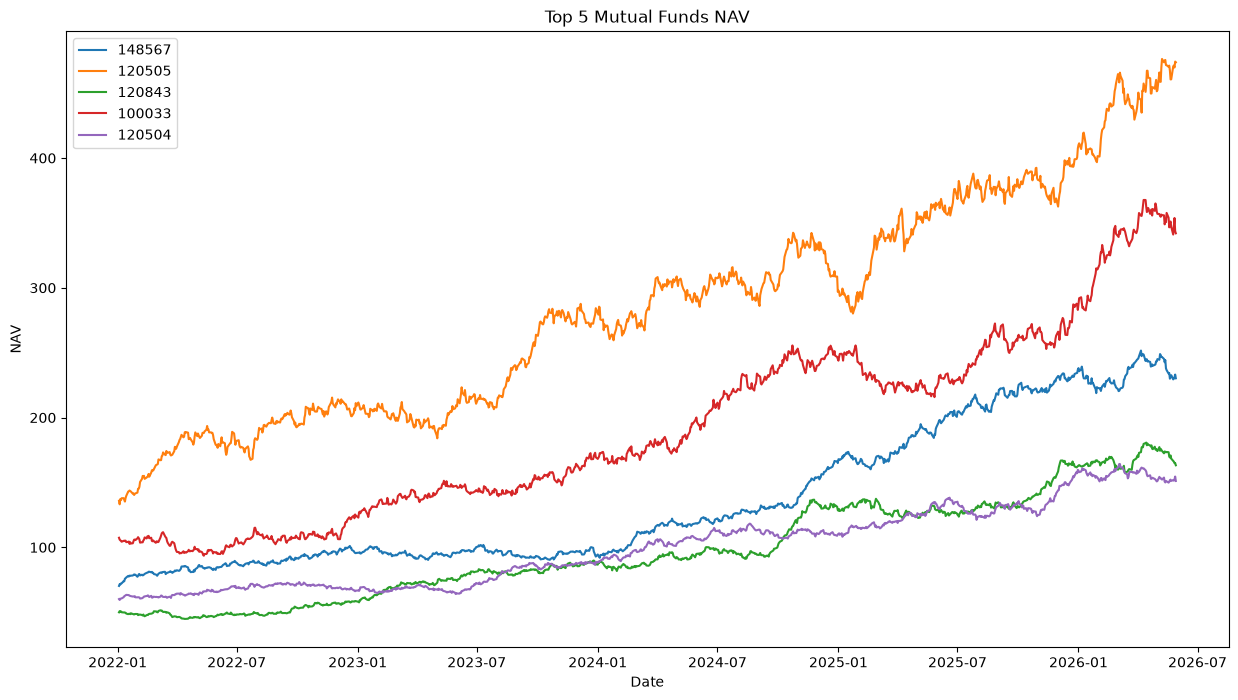

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

for fund in top5["amfi_code"]:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(fund)
    )

plt.title("Top 5 Mutual Funds NAV")

plt.xlabel("Date")

plt.ylabel("NAV")

plt.legend()

plt.show()

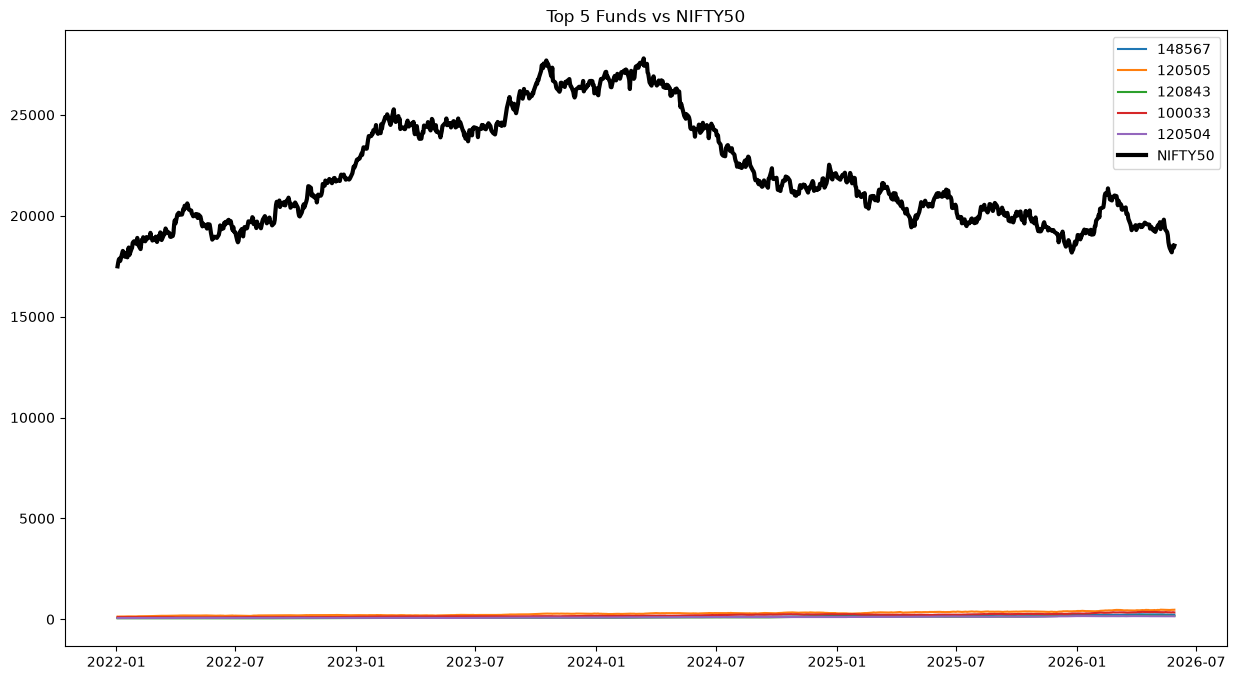

In [71]:
plt.figure(figsize=(15,8))

for fund in top5["amfi_code"]:

    temp = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(fund)
    )

plt.plot(

    nifty50["date"],

    nifty50["close_value"],

    color="black",

    linewidth=3,

    label="NIFTY50"

)

plt.legend()

plt.title("Top 5 Funds vs NIFTY50")

plt.show()

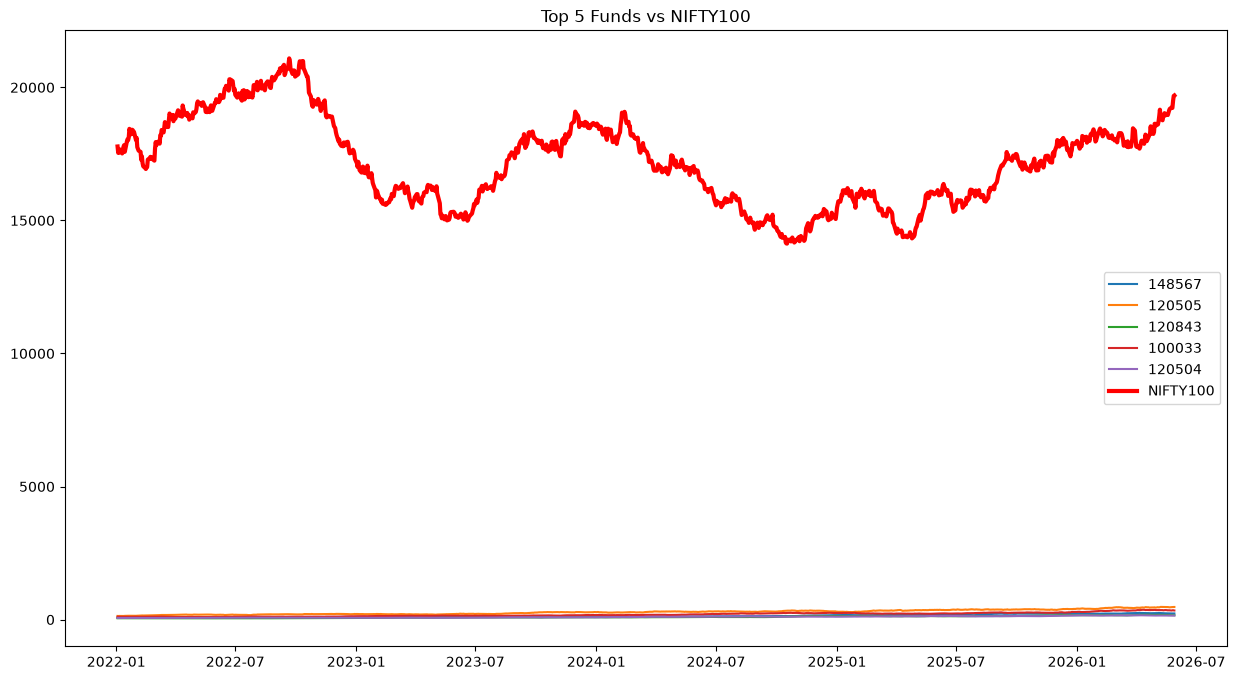

In [72]:
plt.figure(figsize=(15,8))

for fund in top5["amfi_code"]:

    temp = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(fund)
    )

plt.plot(

    nifty100["date"],

    nifty100["close_value"],

    color="red",

    linewidth=3,

    label="NIFTY100"

)

plt.legend()

plt.title("Top 5 Funds vs NIFTY100")

plt.show()

In [73]:
from scipy.stats import linregress
import numpy as np

tracking_error = []

for fund in top5["amfi_code"]:

    fund_df = nav[
        nav["amfi_code"] == fund
    ][["date","daily_return"]]

    merged = pd.merge(

        fund_df,

        nifty100[
            ["date","benchmark_return"]
        ],

        on="date"

    ).dropna()

    te = np.std(

        merged["daily_return"]

        -

        merged["benchmark_return"]

    ) * np.sqrt(252)

    tracking_error.append(
        [fund,te]
    )

tracking_error = pd.DataFrame(

    tracking_error,

    columns=[
        "amfi_code",
        "Tracking_Error"
    ]

)

print(tracking_error)

   amfi_code  Tracking_Error
0     148567        0.189581
1     120505        0.231867
2     120843        0.206335
3     100033        0.228600
4     120504        0.191504


In [74]:
tracking_error.to_csv(

    "../data/processed/tracking_error.csv",

    index=False

)

print("Tracking Error Saved Successfully!")

Tracking Error Saved Successfully!


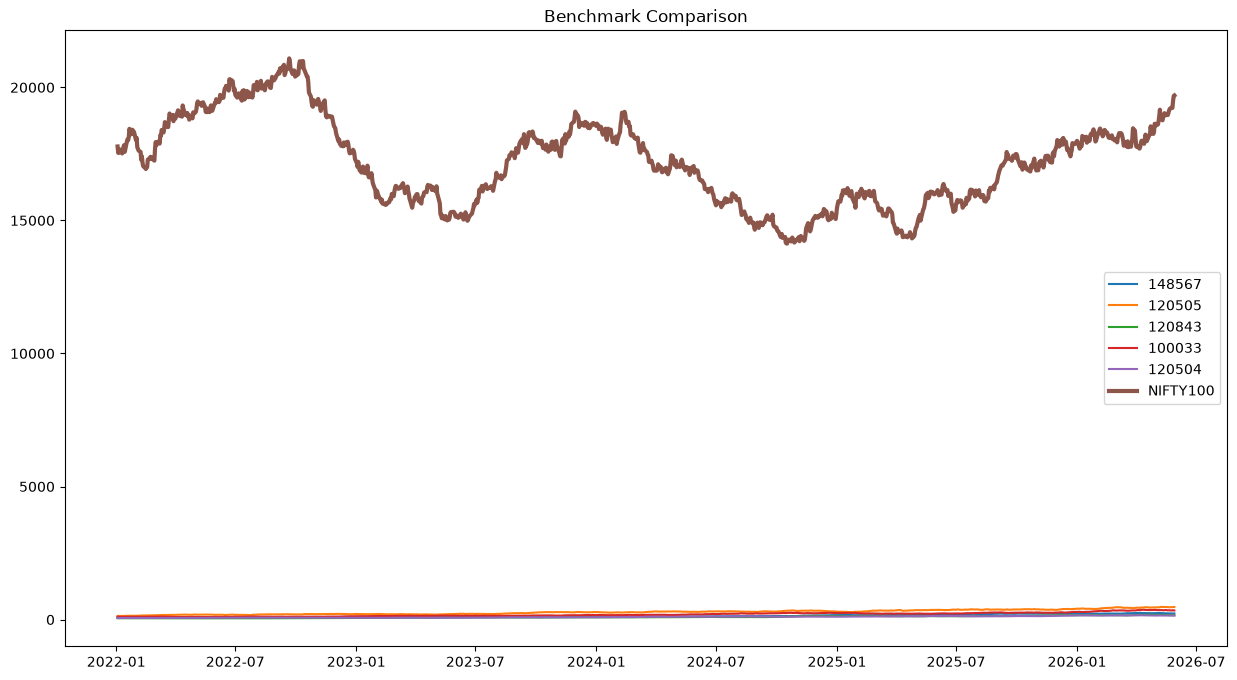

Benchmark Comparison Chart Saved Successfully!


In [75]:
plt.figure(figsize=(15,8))

for fund in top5["amfi_code"]:

    temp = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(

        temp["date"],

        temp["nav"],

        label=str(fund)

    )

plt.plot(

    nifty100["date"],

    nifty100["close_value"],

    linewidth=3,

    label="NIFTY100"

)

plt.legend()

plt.title("Benchmark Comparison")

plt.savefig(

    "../reports/benchmark_comparison.png"

)

plt.show()

print("Benchmark Comparison Chart Saved Successfully!")